In [78]:
import numpy as np

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

import neuromancer.psl as psl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## ⚙️ Training System ID with SINDy


### ⚙️ Define Ground Truth System and Problem Parameters



In [79]:
import numpy as np
from neuromancer.dynamics.ode import ODESystem
from neuromancer.psl.signals import step, sines, periodic, noise, walk
from neuromancer.psl.base import ODE_NonAutonomous as ODE
from neuromancer.psl.base import cast_backend
import torch.nn as nn


In [80]:
import torch


class DiscreteDoubleIntegrator2D:
    """
    Discrete-time system:
        x_{k+1} = A_d x_k + B_d u_k
    State: x = [x1, x2]  (nx = 2)
    Input: u = [ux, uy]  (nu = 2)
    """
    def __init__(self, Ad=None, Bd=None, ts: float = 1.0, device=None):
        self.device = device or torch.device("cpu")
        self._nx, self._nu = 2, 2
        self.ts = ts
        self.Ad = (torch.tensor([[1.0, 0.0],
                                 [0.0, 1.0]], dtype=torch.float32, device=self.device)
                   if Ad is None else torch.as_tensor(Ad, dtype=torch.float32, device=self.device))
        self.Bd = (torch.tensor([[1.0, 0.0],
                                 [0.0, 1.0]], dtype=torch.float32, device=self.device)
                   if Bd is None else torch.as_tensor(Bd, dtype=torch.float32, device=self.device))
        self._umin = torch.tensor([-1.0, -1.0], dtype=torch.float32, device=self.device)
        self._umax = torch.tensor([+1.0, +1.0], dtype=torch.float32, device=self.device)

    @property
    def nx(self): return self._nx
    @property
    def nu(self): return self._nu
    @property
    def umin(self): return self._umin
    @property
    def umax(self): return self._umax

    def get_x0(self):
        return (2.0 * torch.rand(self.nx, device=self.device) - 1.0).to(torch.float32)

    def sample_x0(self, low=-20.0, high=20.0):
        """Uniform in [low, high]^nx."""
        return (low + (high - low) * torch.rand(self.nx, device=self.device)).to(torch.float32)

    def get_U(self, nsim: int, signal=None, **signal_kwargs):
        """
        Piecewise-constant random input of length nsim.
        """
        u = torch.empty(nsim, self.nu, dtype=torch.float32, device=self.device)
        idx = 0
        while idx < nsim:
            seg = int(torch.randint(1, 21, (1,), device=self.device).item())
            seg = min(seg, nsim - idx)
            val = 2.0 * torch.rand(self.nu, device=self.device) - 1.0
            u[idx:idx+seg, :] = val
            idx += seg
        return torch.clamp(u, self.umin, self.umax)

    def step(self, x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        return self.Ad @ x + self.Bd @ u

    @torch.no_grad()
    def simulate(self, nsim: int, ts: float = None):
        """
        Kept for compatibility (single long rollout). Not used by the new datagen.
        """
        X = torch.empty(nsim, self.nx, dtype=torch.float32, device=self.device)
        U = self.get_U(nsim)
        x = self.get_x0()
        for k in range(nsim):
            X[k, :] = x
            x = self.step(x, U[k, :])
        return {"X": X, "U": U}

from typing import Tuple, Dict
import torch
from torch.utils.data import DataLoader
from neuromancer.dataset import DictDataset


def get_data_discrete(
    sys,                 # must expose: nx, nu, step(x,u), get_U(T), sample_x0(low,high)
    nsim: int,
    nsteps: int,
    ts: float,
    bs: int,
    device: torch.device = torch.device("cpu"),
    x0_range = (-20.0, 20.0),
) -> Tuple[DataLoader, DataLoader, Dict[str, torch.Tensor]]:
    """
    Generate train/dev/test with nbatch independent sequences of length nsteps.
    Keeps identical keys/shapes as your ODE pipeline:
      "X":  (nbatch, nsteps, nx)
      "xn": (nbatch, 1, nx)       # first state in each sequence
      "u":  (nbatch, nsteps, nu)
      and per-state: x{i}, x{i}_n
    """
    nx, nu = sys.nx, sys.nu
    nbatch = nsim // nsteps
    length = nbatch * nsteps  # same truncation rule

    def _make_split():
        """
        Build one split dict by sampling nbatch sequences independently.
        """
        # Allocate tensors directly on device
        X = torch.empty(nbatch, nsteps, nx, dtype=torch.float32, device=device)
        U = torch.empty(nbatch, nsteps, nu, dtype=torch.float32, device=device)

        low, high = float(x0_range[0]), float(x0_range[1])

        # Generate each sequence independently
        for b in range(nbatch):
            # inputs for this sequence
            U_seq = sys.get_U(nsteps).to(device=device, dtype=torch.float32)
            U[b, :, :] = U_seq

            # random start within range
            x = sys.sample_x0(low=low, high=high).to(device=device, dtype=torch.float32)

            # roll nsteps with recorded pre-control states
            for k in range(nsteps):
                X[b, k, :] = x
                x = sys.step(x, U_seq[k, :])

        return {"X": X, "U": U}

    # three independent splits
    train_sim = _make_split()
    dev_sim   = _make_split()
    test_sim  = _make_split()

    def _tensorise(sim_dict: Dict[str, torch.Tensor], keep_1d: bool = False) -> Dict[str, torch.Tensor]:
        X_t = sim_dict["X"]  # (nbatch, nsteps, nx)
        U_t = sim_dict["U"]  # (nbatch, nsteps, nu)

        out: Dict[str, torch.Tensor] = {
            "X": X_t,
            "xn": X_t[:, 0:1, :],
            "u": U_t,
        }
        if keep_1d:
            for i in range(nx):
                xi = X_t[:, :, i:i+1]
                out[f"x{i}"]    = xi
                out[f"x{i}_n"]  = xi[:, 0:1, :]
        return out

    train_dict = _tensorise(train_sim, keep_1d=True)
    dev_dict   = _tensorise(dev_sim, keep_1d=True)

    train_data = DictDataset(train_dict, name="train")
    dev_data   = DictDataset(dev_dict,   name="dev")

    train_loader = DataLoader(train_data, batch_size=bs, shuffle=True,
                              collate_fn=train_data.collate_fn)
    dev_loader   = DataLoader(dev_data,   batch_size=bs, shuffle=True,
                              collate_fn=dev_data.collate_fn)

    # Test set: keep your expected shape (1, test_length, ·)
    test_length = length
    # Build a single long test rollout from a random start, still bounded
    low, high = float(x0_range[0]), float(x0_range[1])
    U_test = sys.get_U(test_length).to(device=device, dtype=torch.float32)
    X_test = torch.empty(test_length, nx, dtype=torch.float32, device=device)
    x = sys.sample_x0(low=low, high=high).to(device=device, dtype=torch.float32)
    for k in range(test_length):
        X_test[k, :] = x
        x = sys.step(x, U_test[k, :])

    test_raw = {
        "X": X_test.reshape(1, test_length, nx),
        "U": U_test.reshape(1, test_length, nu),
    }
    test_dict = _tensorise(test_raw, keep_1d=True)

    return train_loader, dev_loader, test_dict


In [81]:
# Ground truth system model
gt_model = DiscreteDoubleIntegrator2D()

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = -1.
umax = +1.
xmin = -10.
xmax = +10.


In [82]:
# build library once
lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=False,
    include_bias=True, max_degree=2,
    add_sqrt=True, add_xu=True, add_u_prod=True,
    add_fourier=True, max_freq=1
)

# create model (multi-output)
sindy = SINDyVectorized(library=lib, n_out=nx, device=device)
sindy.pretty_print()

dx0/dt = +1.1470e-02·1 + -1.1899e-02·x0 + +1.3711e-02·x1 + -2.5539e-03·u0 + +2.1359e-02·u1 + +1.1904e-02·sqrt(x0) + -5.7467e-03·sqrt(x1) + -4.0423e-02·x0^2 + +1.1416e-02·x0*x1 + -4.4267e-02·x1^2 + +6.5714e-03·u0*u1 + +3.3229e-03·x0*u0 + -1.0995e-02·x0*u1 + +4.0885e-02·x1*u0 + +3.3368e-03·x1*u1 + +2.0734e-02·sin(1·x0) + +2.1160e-02·sin(1·x1) + -2.9497e-02·cos(1·x0) + -1.9222e-02·cos(1·x1)
dx1/dt = +4.8086e-02·1 + -4.8974e-02·x0 + -3.3959e-03·x1 + -3.9625e-03·u0 + +3.5465e-02·u1 + -4.7535e-03·sqrt(x0) + +1.3166e-02·sqrt(x1) + -2.4002e-03·x0^2 + -2.7997e-02·x0*x1 + -2.8340e-02·x1^2 + -2.4292e-02·u0*u1 + -4.5420e-02·x0*u0 + -3.2449e-02·x0*u1 + +1.1767e-02·x1*u0 + +3.2907e-02·x1*u1 + +2.4631e-03·sin(1·x0) + -2.2919e-02·sin(1·x1) + +2.1974e-02·cos(1·x0) + -1.9194e-02·cos(1·x1)


In [83]:
nsim   = 3000
nsteps = 2
bs     = 3000

train_loader, dev_loader, test_data = get_data_discrete(
    gt_model, nsim, nsteps, gt_model.ts, bs, device=device, x0_range=(-20.0, 20.0)
)


In [84]:
print(train_loader.dataset.datadict["X"].max())
print(train_loader.dataset.datadict["X"].min())

tensor(20.8280)
tensor(-20.6781)


### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


In [85]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 1e-9,     # L¹ sparsity on SINDy coefficients
    "l1_decay"       : 0.3,

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 20000,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 0.01,     # initial coefficient cutoff
    "prune_every"    : 5000,    # epochs between pruning passes
    "threshold_mult" : 1.05,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


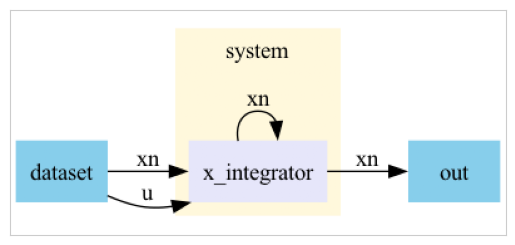

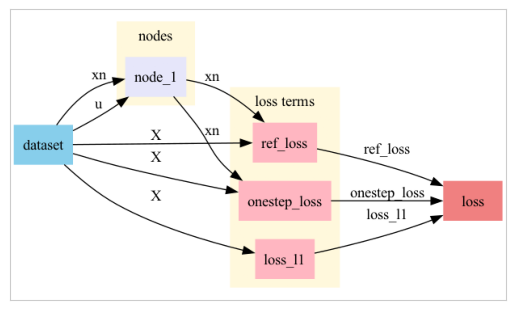

None


In [86]:

from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators


# One-element integrator for current state
integrator_node_x = Node(sindy, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.show()

x = variable(f"X")
x_hat = variable(f'xn')[:, :-1, :]

# Define losses
onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
onestep_loss_x.name = "onestep_loss"

reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
reference_loss_x.name = "ref_loss"

# L1 sparsity regularization on model weights
l1_x = variable([x], lambda x: sum(torch.norm(p, p=1) for p in sindy.Xi))
loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
loss_l1_x.name = "loss_l1"

# Assemble problem
objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
loss_x = PenaltyLoss(objectives_x, [])
problem_x = Problem([dynamics_model_x], loss_x)
problem_x.show()

lr = dyn_cfg["lr"]
optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

logger = CustomLogger(
    args=None,
    savedir='test',
    verbosity=200,
    stdout=['train_loss','dev_loss']
)




In [87]:

trainer_x = SparseTrainer(
    problem=problem_x,
    sindy=sindy,
    lr=lr,
    train_data=None,
    test_data=None,
    optimizers=optimizer_x,
    epochs=dyn_cfg["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=logger,
    device= device,
    threshold=dyn_cfg["threshold"],
    prune_every=dyn_cfg["prune_every"],
    warmup=300,
    patience=50,
    threshold_mult=dyn_cfg["threshold_mult"],
    prune_noise=dyn_cfg["prune_noise"],
    l1_decay=dyn_cfg["l1_decay"],
)

# Regenerate training data for updated horizon
trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
trainer_x.problem = problem_x

# Train
best_model = trainer_x.train()
trainer_x.model.load_state_dict(best_model)


epoch: 0	train_loss: 4.755e+02	dev_loss: 4.755e+02	eltime:  0.16368
epoch: 200	train_loss: 1.386e+02	dev_loss: 1.396e+02	eltime:  10.49361
epoch: 400	train_loss: 6.039e+01	dev_loss: 6.120e+01	eltime:  20.18714
epoch: 600	train_loss: 1.580e+01	dev_loss: 1.613e+01	eltime:  29.59961
epoch: 800	train_loss: 2.587e+00	dev_loss: 2.671e+00	eltime:  38.98132
epoch: 1000	train_loss: 5.164e-01	dev_loss: 5.389e-01	eltime:  48.23613
epoch: 1200	train_loss: 2.563e-01	dev_loss: 2.660e-01	eltime:  57.57730
epoch: 1400	train_loss: 2.237e-01	dev_loss: 2.306e-01	eltime:  66.95248
epoch: 1600	train_loss: 2.146e-01	dev_loss: 2.202e-01	eltime:  76.79405
epoch: 1800	train_loss: 2.083e-01	dev_loss: 2.133e-01	eltime:  86.14286
epoch: 2000	train_loss: 2.023e-01	dev_loss: 2.069e-01	eltime:  95.50633
epoch: 2200	train_loss: 1.964e-01	dev_loss: 2.009e-01	eltime:  104.73616
epoch: 2400	train_loss: 1.897e-01	dev_loss: 1.938e-01	eltime:  114.08413
epoch: 2600	train_loss: 1.828e-01	dev_loss: 1.867e-01	eltime:  123.439

<All keys matched successfully>

In [88]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x0 + +1.0000e+00·u0
dx1/dt = +9.9991e-01·x1 + +1.0001e+00·u1


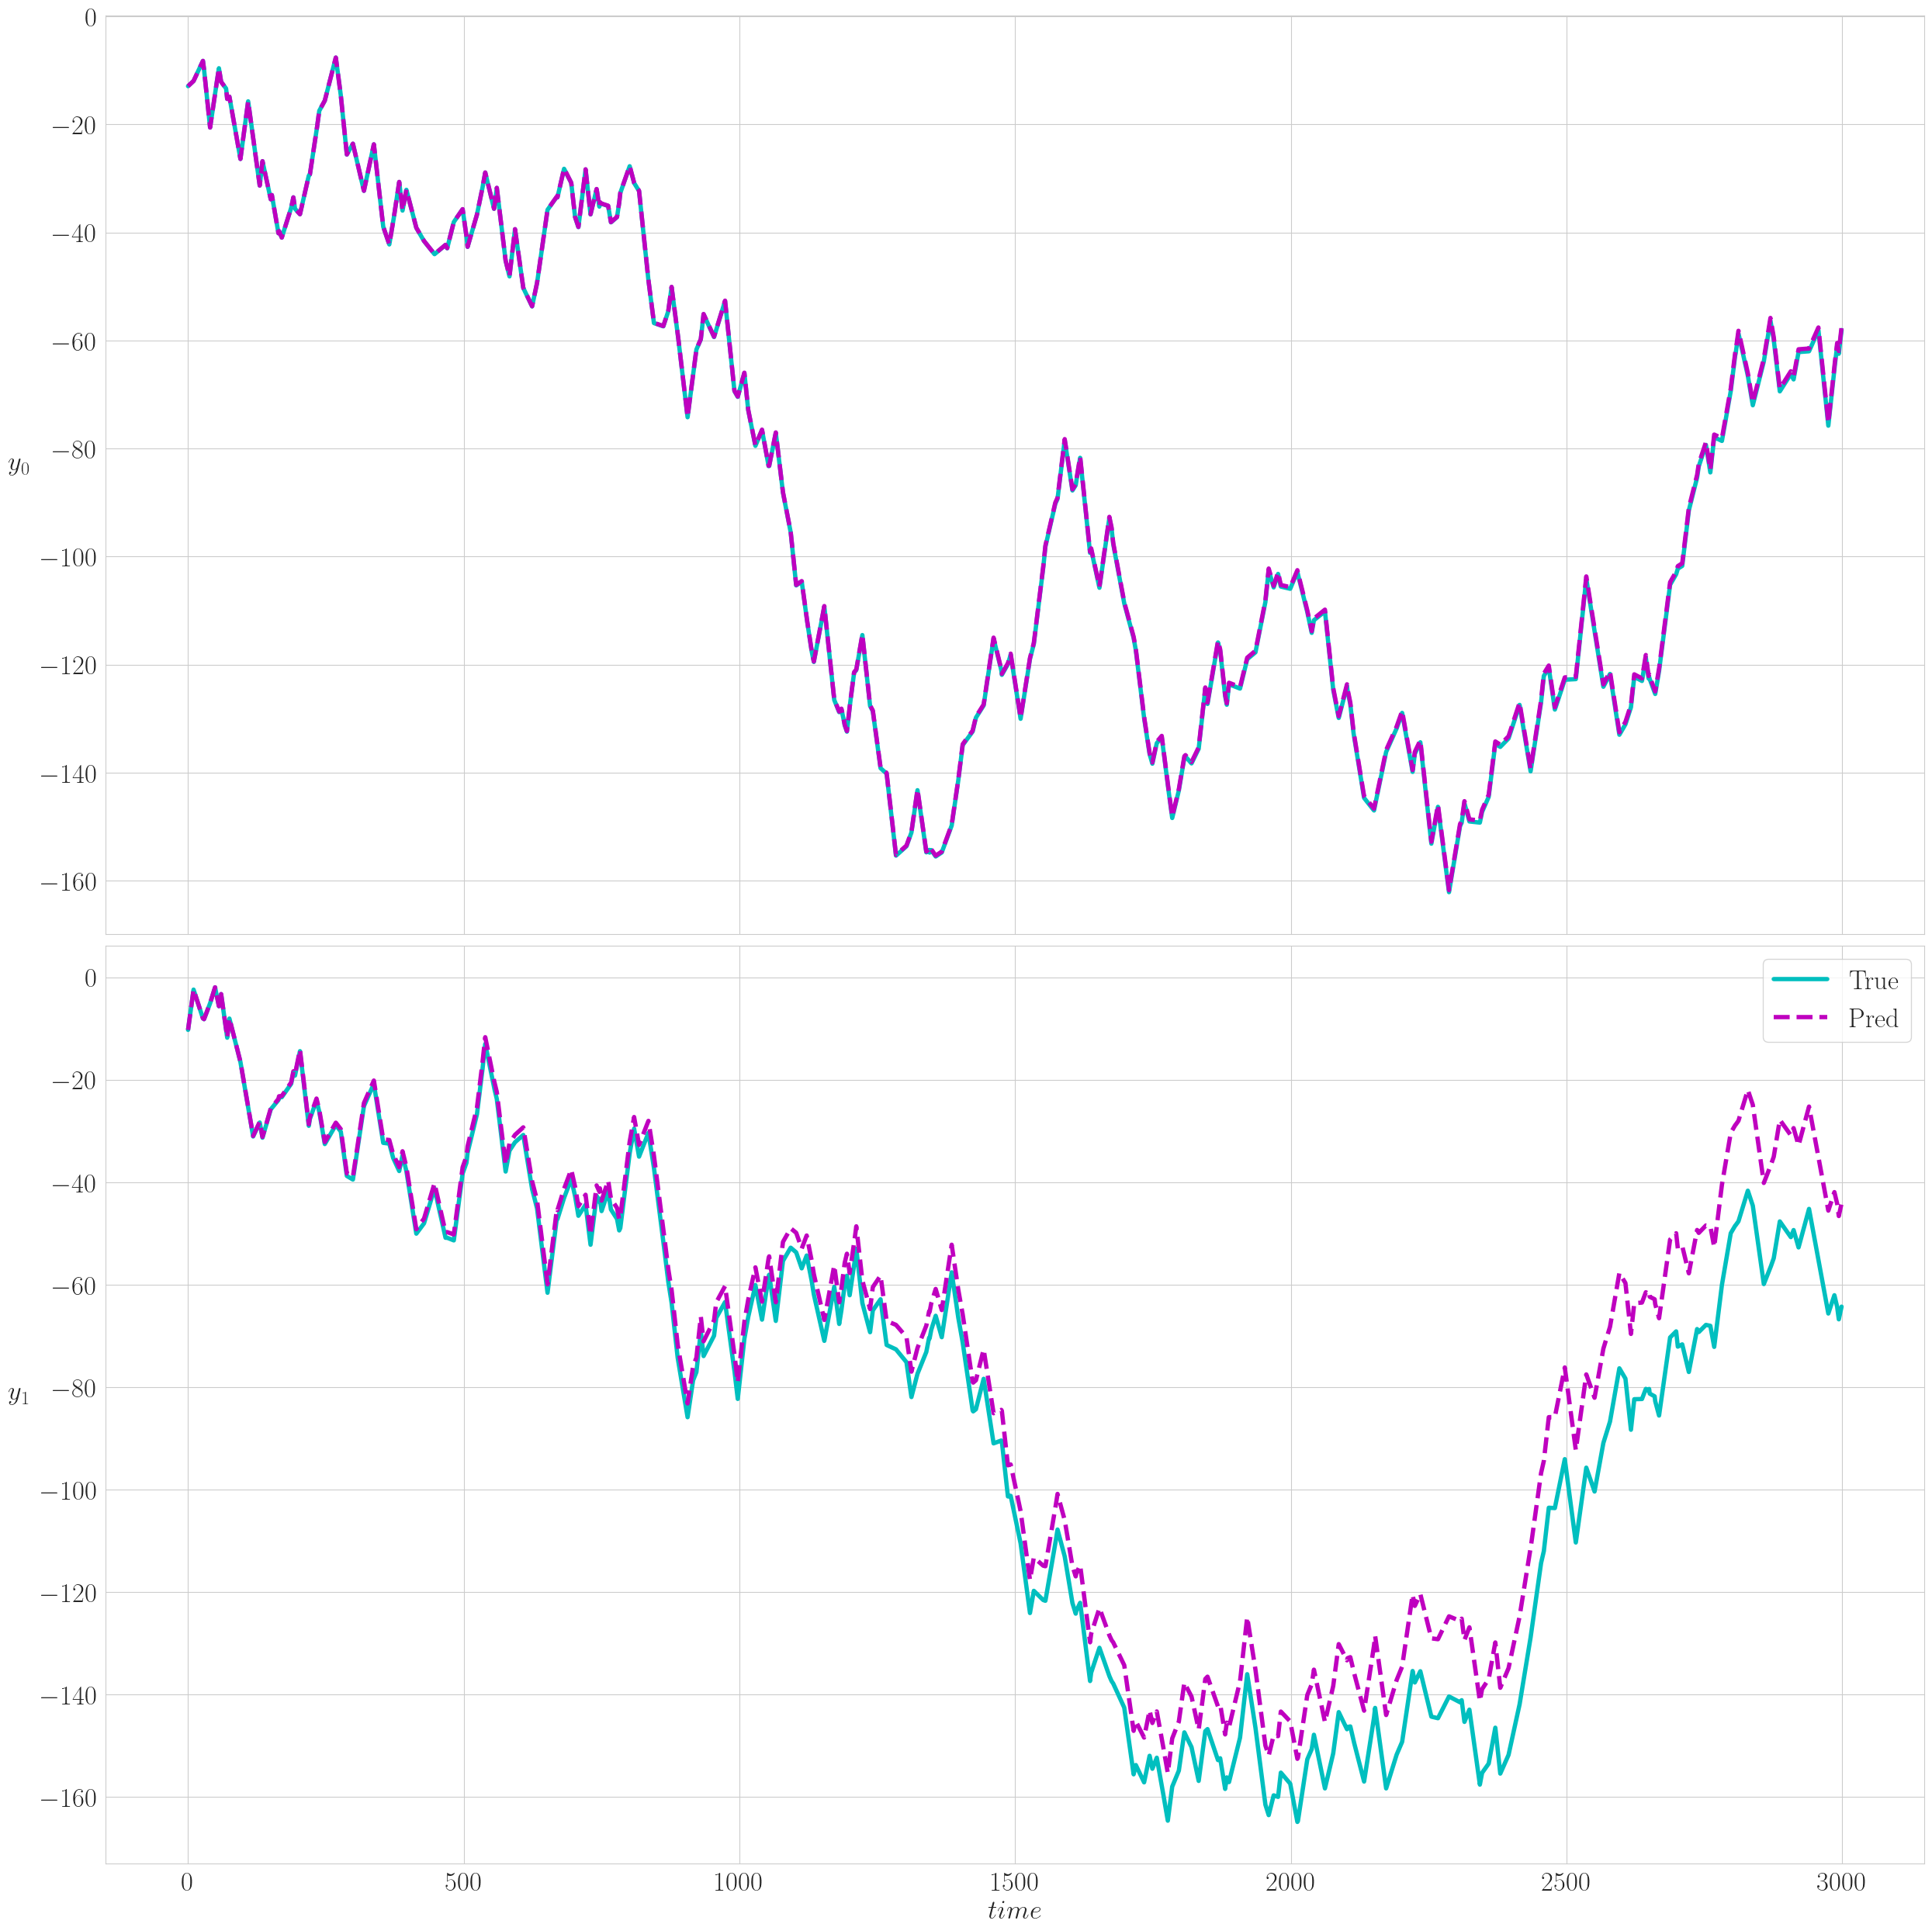

In [89]:
import matplotlib.pyplot as plt

# Create system for evaluation
sindy_system = System([integrator_node_x], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()



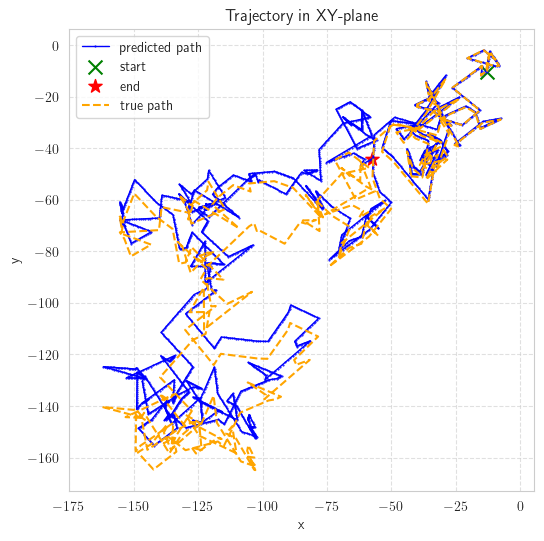

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
def plot_traj(pred_traj, true_traj=None, title="Trajectory in XY-plane"):
    """
    pred_traj: numpy array of shape (4, T)
               rows: [x, xdot, y, ydot]
    true_traj: numpy array of shape (4, T) (optional)
    """
    x_pred = pred_traj[0, :]
    y_pred = pred_traj[1, :]

    plt.figure(figsize=(6,6))
    # predicted
    plt.plot(x_pred, y_pred, marker="o", markersize=0.5, linewidth=1.0,
             label="predicted path", color="blue")
    plt.scatter(x_pred[0], y_pred[0], c="green", marker="x", s=100, label="start")
    plt.scatter(x_pred[-1], y_pred[-1], c="red", marker="*", s=100, label="end")

    # true path if given
    if true_traj is not None:
        x_true = true_traj[0, :]
        y_true = true_traj[1, :]
        plt.plot(x_true, y_true, linewidth=1.5, linestyle="--", color="orange", label="true path")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

# Example:
plot_traj(pred_traj, true_traj)


#### Save model

In [91]:
import json, torch
from pathlib import Path

sindy_lib_cfg = dict(
    n_features=lib.n_features,
    n_control=lib.n_control,
    include_bias=lib.include_bias,
    max_degree=lib.max_degree,
    add_sqrt=lib.add_sqrt,
    add_xu=lib.add_xu,
    add_u_prod=lib.add_u_prod,
    add_fourier=lib.add_fourier,
    max_freq=lib.max_freq,
    is_policy=lib.is_policy,
)

sindy_model_cfg = dict(
    n_out=sindy.n_out,
)

ckpt = {
    "lib_cfg": sindy_lib_cfg,
    "model_cfg": sindy_model_cfg,
    "active_idx": sindy.active_idx,          # list[list[int]]
    "state_dict": sindy.state_dict(),        # weights
}


# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/models/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(dyn_cfg, indent=4)))

models_dir = run_dir / "saved_models"; models_dir.mkdir()
torch.save(ckpt, str(models_dir) + "/sindy.pt")   # you can call it .pkl if you want


## POlicy

In [92]:
from typing import Tuple, Optional
import torch
from torch.utils.data import DataLoader
from neuromancer.dataset import DictDataset


def get_policy_data(
    nsteps: int,
    n_samples: int,
    nx: int,
    device: torch.device,
    *,
    batch_size: int = 200,
    seed: Optional[int] = None,
    # Rectangles are ((x_min, y_min), (x_max, y_max))
    init_rect: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    ref_rect:  Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    # Ellipse parameters for obstacle exclusion
    ellipse_configs: dict = {"p": 10.0, "b": 8.0, "c": 1.0, "d": 2.0},
) -> Tuple[DataLoader, DataLoader]:
    """
    Positions-only version (state = [x, y], nx must be 2).

    Generates training/dev sets:
      - Initial positions sampled uniformly in init_rect; state = [x, y].
      - Reference positions sampled uniformly in ref_rect, held constant over horizon.
      - Samples that fall INSIDE the obstacle ellipse are rejected.

    Returns:
      train_loader, dev_loader
    """
    assert nx == 2, f"positions-only state requires nx == 2, got nx={nx}"

    # RNG
    if seed is None:
        gen_train = gen_dev = None
    else:
        gen_train = torch.Generator(device=device).manual_seed(seed)
        gen_dev   = torch.Generator(device=device).manual_seed(seed + 1)

    # Ellipse params
    p = float(ellipse_configs["p"])
    b = float(ellipse_configs["b"])
    c = float(ellipse_configs["c"])
    d = float(ellipse_configs["d"])
    assert b > 0.0 and p >= 0.0

    def outside_ellipse(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # keep points whose quadratic form is >= (p/2)^2 (i.e., OUTSIDE the ellipse)
        return (b * (x - c)**2 + (y - d)**2) >= (p * 0.5)**2

    def sample_xy_in_rect_outside(
        n: int,
        rect: Tuple[Tuple[float, float], Tuple[float, float]],
        gen: Optional[torch.Generator],
        max_iters: int = 100,
        chunk: int = 4096,
    ) -> torch.Tensor:
        (x0, y0), (x1, y1) = rect
        # allow unordered corners
        if x1 < x0: x0, x1 = x1, x0
        if y1 < y0: y0, y1 = y1, y0
        assert x1 > x0 and y1 > y0, "Rectangle must have positive width/height."

        out = torch.empty(0, 2, device=device, dtype=torch.float32)
        need = n
        it = 0
        while need > 0 and it < max_iters:
            m = max(need, chunk)
            xs = x0 + (x1 - x0) * torch.rand((m,), device=device, generator=gen)
            ys = y0 + (y1 - y0) * torch.rand((m,), device=device, generator=gen)
            keep = outside_ellipse(xs, ys)
            if keep.any():
                block = torch.stack([xs[keep], ys[keep]], dim=1).to(torch.float32)
                out = torch.cat([out, block], dim=0)
                need = n - out.shape[0]
            it += 1

        if out.shape[0] < n:
            raise RuntimeError(
                f"Could not sample {n} points outside the ellipse within the given rectangle "
                f"after {it} iterations. Consider changing the rectangle or the ellipse."
            )
        return out[:n]

    def _build_split(name: str, gen: Optional[torch.Generator]) -> "DictDataset":
        # Initial state: positions in init_rect but OUTSIDE ellipse
        xy0 = sample_xy_in_rect_outside(n_samples, init_rect, gen)   # (n_samples, 2)
        xn = xy0.view(n_samples, 1, 2).to(device=device, dtype=torch.float32)  # (n_samples, 1, nx=2)

        # Reference positions (constant over horizon) in ref_rect, OUTSIDE ellipse
        xy_ref = sample_xy_in_rect_outside(n_samples, ref_rect, gen)             # (n_samples, 2)
        r = torch.empty((n_samples, nsteps + 1, 2), device=device, dtype=torch.float32)
        r[:, :, 0] = xy_ref[:, 0].unsqueeze(1).expand(-1, nsteps + 1)
        r[:, :, 1] = xy_ref[:, 1].unsqueeze(1).expand(-1, nsteps + 1)

        dct = {
            "xn": xn,                        # (n_samples, 1, 2)  -> state = [x, y]
            "r": r,                          # (n_samples, nsteps+1, 2)
            "obs_p": torch.full((n_samples, 1, 1), p, device=device),
            "obs_b": torch.full((n_samples, 1, 1), b, device=device),
            "obs_c": torch.full((n_samples, 1, 1), c, device=device),
            "obs_d": torch.full((n_samples, 1, 1), d, device=device),
        }
        return DictDataset(dct, name=name)

    train_data = _build_split("train", gen_train)
    dev_data   = _build_split("dev",   gen_dev)

    train_loader = DataLoader(train_data, batch_size=batch_size,
                              shuffle=False, collate_fn=train_data.collate_fn)
    dev_loader   = DataLoader(dev_data, batch_size=batch_size,
                              shuffle=False, collate_fn=dev_data.collate_fn)
    return train_loader, dev_loader


In [93]:
ellipse_configs = {"p": 3,
                   "b": 1,
                   "c": 0.0,
                   "d": 0.0,
                   "theta": 0.0}

def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

xmin = -5.
xmax = 5.
umin = -1.0
umax = 1.0

side = 3
init_center = (3, -3)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-3,3)
ref_rect = make_square(ref_center, side)


nsteps = 40


train_loader, dev_loader = get_policy_data(
    nsteps=nsteps, n_samples=5000, nx=nx, batch_size=400 ,device=device,
    ellipse_configs=ellipse_configs,
    init_rect=init_rect, ref_rect=ref_rect,
)


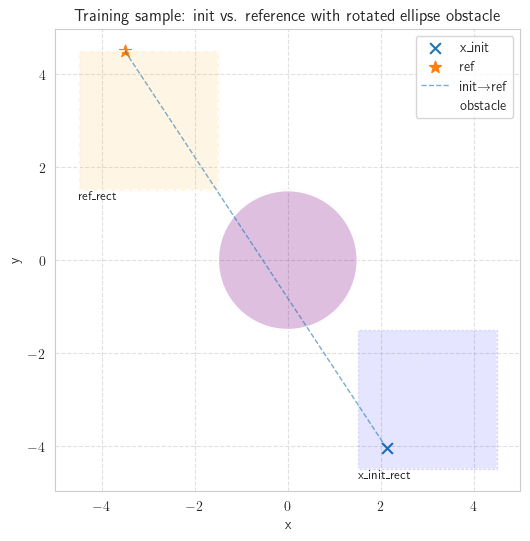

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Training sample: init vs. reference with rotated ellipse obstacle'}, xlabel='x', ylabel='y'>)

In [94]:
# plotting a data sample from train loader
plot_training_sample_with_ellipse(
    train_loader,
    sample_idx=32,
    pos_idx=(0, 1),
    init_rect=init_rect,
    ref_rect=ref_rect,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    theta=ellipse_configs["theta"],
    xmin=xmin, xmax=xmax
)

In [95]:
train_loader.dataset.datadict.keys()

dict_keys(['xn', 'r', 'obs_p', 'obs_b', 'obs_c', 'obs_d'])

In [96]:
import importlib
import SparseDPC.vectorized.trainer

importlib.reload(SparseDPC.vectorized.trainer)
from SparseDPC.vectorized.trainer import SparsePolicyBuilder2D

In [122]:

pol_configs = {
    "l1_coef": 0.00001,
    "Q_con_obs": 1000.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 16.0,
    "Q_uf": 1.0,
    "Q_r": 100.0,
    "Q_dx": 0.0,
    "Q_du": 1.0,
    "lr": 0.002,
    "epochs": 10000,
    "threshold": 0.005,
    "prune_every": 1000,
    "prune_every_min": 500,
    "prune_every_decay": 100,
    "change_prune_every": True,
    "threshold_mult": 1.3,
    "threshold_max" : 0.012,
    "prune_noise": 0.01,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
}

refstep=1
policies_seed = 5

None


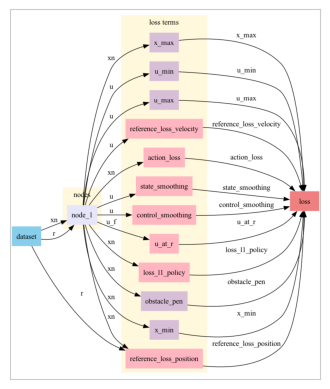

In [123]:
# build library once
policy_lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=True,
    include_bias=True, max_degree=2,
    add_sqrt=False, add_xu=True, add_u_prod=True,
    add_fourier=True, max_freq=2
)

nn_config = {
    "layers": [32, 32],
    "reg_coef": 20.0,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 1000,
    "warmup": 1000,
    "patience": 400,
}

from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
policy_neural = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)

# create model (multi-output)
policy_sparse = SINDyVectorized(library=policy_lib, n_out=nu, policy_name=["u0","u1"], device=device, seed=policies_seed)
builder_SD_SINDy = SparsePolicyBuilder2D(
    dynamics_model= sindy,
    policy        = policy_sparse,
    is_sindy      = True,
    gt_model      = None,
    ts            = 1.0,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    obstacle_configs = ellipse_configs,
    refstep = refstep,
    seed          = policies_seed,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [124]:
builder_SD_SINDy.policy.pretty_print()

u0 = +3.3025e-02·1 + -3.7389e-02·x0 + +4.0747e-02·x1 + +3.1993e-02·r0 + +4.2010e-02·r1 + -3.8335e-02·x0^2 + -3.3561e-02·x0*x1 + +2.3792e-02·x1^2 + -4.6674e-02·r0*r1 + +4.9418e-02·x0*r0 + +1.0643e-02·x0*r1 + +6.4571e-03·x1*r0 + -4.2759e-02·x1*r1 + +1.5934e-02·sin(1·x0) + +2.1501e-02·sin(2·x0) + +7.9328e-03·sin(1·x1) + +4.8093e-02·sin(2·x1) + +1.5016e-02·cos(1·x0) + -4.4337e-02·cos(2·x0) + +4.2011e-02·cos(1·x1) + +1.6976e-02·cos(2·x1) + -2.3853e-02·sin(1·r0) + -4.5928e-02·sin(2·r0) + +2.8504e-02·sin(1·r1) + +4.7516e-02·sin(2·r1) + -4.0966e-02·cos(1·r0) + +2.7325e-03·cos(2·r0) + +1.7939e-02·cos(1·r1) + -2.3612e-02·cos(2·r1)
u1 = -1.0940e-02·1 + -3.3386e-02·x0 + -2.3638e-02·x1 + -4.5583e-02·r0 + -1.1588e-03·r1 + +2.9646e-02·x0^2 + +2.4319e-02·x0*x1 + +4.6970e-02·x1^2 + -4.3913e-02·r0*r1 + -6.1521e-03·x0*r0 + +4.8682e-02·x0*r1 + +8.1875e-03·x1*r0 + -1.4100e-02·x1*r1 + -4.5030e-02·sin(1·x0) + +2.3267e-02·sin(2·x0) + +3.7959e-02·sin(1·x1) + +4.0094e-02·sin(2·x1) + +4.1858e-02·cos(1·x0) + +9.7

In [125]:
builder_SD_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([400, 40, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([400, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 40, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss =

epoch: 0	train_loss: 1.278e+03	dev_loss: 1.357e+03	eltime:  2.16355
epoch: 10	train_loss: 2.784e+02	dev_loss: 2.931e+02	eltime:  12.56106
epoch: 20	train_loss: 1.832e+02	dev_loss: 1.930e+02	eltime:  22.05611
epoch: 30	train_loss: 1.326e+02	dev_loss: 1.379e+02	eltime:  31.73147
epoch: 40	train_loss: 9.153e+01	dev_loss: 9.485e+01	eltime:  41.25596
epoch: 50	train_loss: 5.678e+01	dev_loss: 5.820e+01	eltime:  50.99876
epoch: 60	train_loss: 2.782e+01	dev_loss: 2.933e+01	eltime:  60.50912
epoch: 70	train_loss: 1.308e+01	dev_loss: 1.386e+01	eltime:  69.87381
epoch: 80	train_loss: 8.756e+00	dev_loss: 9.305e+00	eltime:  79.40745
epoch: 90	train_loss: 7.143e+00	dev_loss: 7.593e+00	eltime:  88.90846
epoch: 100	train_loss: 6.184e+00	dev_loss: 6.631e+00	eltime:  98.39593
epoch: 110	train_loss: 5.508e+00	dev_loss: 5.972e+00	eltime:  107.86871
epoch: 120	train_loss: 4.967e+00	dev_loss: 5.423e+00	eltime:  117.61584
epoch: 130	train_loss: 4.514e+00	dev_loss: 4.942e+00	eltime:  127.18975
epoch: 140	trai

In [110]:
A_noisy = torch.tensor([[1.0, -0.2],
                         [0.0, 1.0]], dtype=torch.float32, device=device)
B_noisy = torch.tensor([[1.2, 0.0],
                         [0.0, 0.8]], dtype=torch.float32, device=device)

def noisy_system (x,u):
    x_next =  x @A_noisy.T + u @ B_noisy.T
    return x_next

gt_integrator_node = Node(sindy, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn,r : torch.clamp(builder_SD_SINDy.policy(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

import copy
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))

In [111]:
import importlib
import SparseDPC.vectorized.plot

importlib.reload(SparseDPC.vectorized.plot)
from SparseDPC.vectorized.plot import plot_trajectories_with_ellipse

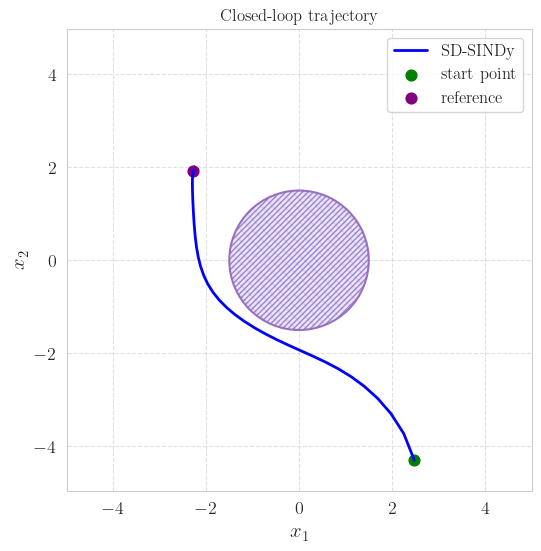

In [126]:
seed =8
nsteps_test = 40
data = make_test_sample(
    nx=nx, nsteps=nsteps_test, seed= seed
    , device=device,
    ellipse= ellipse_configs,
    init_rect= init_rect,
    ref_rect= ref_rect,
)

# Simulate system
gt_sindy_policy_system.nsteps = nsteps_test


trajectories = gt_sindy_policy_system(data)


traj_x = trajectories["xn"]
traj_r = trajectories['r']


fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "SD-SINDy", "color": "blue"},
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


## MPC

In [127]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def solve_and_plot_ipopt(
    sample: dict,
    pol_configs: dict,
    *,
    ts: float,
    # discrete dynamics x_{k+1} = Ad x_k + Bd u_k
    Ad=None,
    Bd=None,
    ellipse_cfg: dict | None = None,
    bounds: dict | None = None,
    # objective shaping
    track_whole_horizon: bool = True,   # True → track ref along horizon; False → terminal-only (last refstep)
    refstep: int = 1,
    add_state_smoothing: bool = True,
    add_control_smoothing: bool = True,
    title_xy: str = "IPOPT trajectory with keep-out ellipse (discrete 2D)",
):
    """
    Solve:
        minimize_u  J(X,U)
        subject to  X_{k+1} = Ad X_k + Bd U_k
                    box constraints on X and U
    where X = [x, y] ∈ R^2 and U = [ux, uy] ∈ R^2.

    Inputs
    ------
    sample['xn'] : (1,1,2)  initial state (positions only)
    sample['r']  : (1,N+1,2) reference positions over horizon (constant allowed)
    ts           : sampling time (used for plotting only unless Bd is None)

    Ad, Bd       : optional discrete matrices (2x2). If None:
                   Ad = I_2, Bd = ts * I_2  (position integrator on u)

    ellipse_cfg  : dict with keys {p,b,c,d} for keep-out ellipse
                   b*(x-c)^2 + (y-d)^2 >= (p/2)^2
    bounds       : dict with keys {xmin, xmax, umin, umax}
                   each can be scalar or length-2 array-like

    Returns
    -------
    Xsol : (2, N+1) optimal states
    Usol : (2, N)   optimal inputs
    J    : float    objective value
    (fig1, ax1), (fig2, axs) : matplotlib handles
    """
    # -------------------- unpack data --------------------
    assert 'xn' in sample and 'r' in sample, "sample must have 'xn' and 'r'"
    x0 = sample['xn'][0, 0, :].detach().cpu().numpy()        # (2,)
    R  = sample['r'][0].detach().cpu().numpy()               # (N+1,2)
    assert x0.shape == (2,)
    assert R.ndim == 2 and R.shape[1] == 2
    N  = R.shape[0] - 1                                      # horizon length

    # Default discrete dynamics
    if Ad is None:
        Ad = np.eye(2)
    if Bd is None:
        Bd = ts * np.eye(2)
    Ad = np.asarray(Ad, dtype=float).reshape(2, 2)
    Bd = np.asarray(Bd, dtype=float).reshape(2, 2)
    Ad_cs = ca.DM(Ad)
    Bd_cs = ca.DM(Bd)

    # Ellipse params
    if ellipse_cfg is None:
        ellipse_cfg = dict(p=4.0, b=1.0, c=0.0, d=0.0)
    p = float(ellipse_cfg['p'])
    b = float(ellipse_cfg['b'])
    cC = float(ellipse_cfg['c'])
    dC = float(ellipse_cfg['d'])
    assert b > 0.0 and p >= 0.0
    r2_boundary = (p * 0.5) ** 2

    # Bounds
    if bounds is None:
        bounds = dict(xmin=-2.0, xmax=2.0, umin=-1.0, umax=1.0)

    def to_arr(val, dim):
        if np.isscalar(val): return np.full(dim, float(val))
        arr = np.asarray(val, dtype=float)
        assert arr.shape == (dim,)
        return arr

    xmin = to_arr(bounds['xmin'], 2)
    xmax = to_arr(bounds['xmax'], 2)
    umin = to_arr(bounds['umin'], 2)
    umax = to_arr(bounds['umax'], 2)

    # Weights
    Q_con_obs = float(pol_configs.get("Q_con_obs", 100.0))
    Q_con_x   = float(pol_configs.get("Q_con_x",   10.0))
    Q_u       = float(pol_configs.get("Q_u",        0.1))
    Q_r       = float(pol_configs.get("Q_r",        2.0))
    Q_dx      = float(pol_configs.get("Q_dx",       0.1))
    Q_du      = float(pol_configs.get("Q_du",       0.1))

    # -------------------- CasADi variables --------------------
    opti = ca.Opti()
    X = opti.variable(2, N+1)     # [x, y] over horizon
    U = opti.variable(2, N)       # [ux, uy] over horizon

    # -------------------- dynamics (discrete) --------------------
    for k in range(N):
        xk = X[:, k]
        uk = U[:, k]
        xk_next = X[:, k+1]
        opti.subject_to(xk_next == Ad_cs @ xk + Bd_cs @ uk)

    # Initial condition
    opti.subject_to(X[:, 0] == x0)

    # -------------------- bounds --------------------
    for i in range(2):
        opti.subject_to(opti.bounded(xmin[i], X[i, :], xmax[i]))
        opti.subject_to(opti.bounded(umin[i], U[i, :], umax[i]))

    # -------------------- objective --------------------
    obj = 0

    # 1) tracking (positions only)
    if track_whole_horizon:
        for k in range(N+1):
            rx, ry = R[k, 0], R[k, 1]
            obj += Q_r * ca.sumsqr(X[:, k] - ca.vertcat(rx, ry))
    else:
        # terminal-only (last `refstep` samples)
        rxN, ryN = R[-1, 0], R[-1, 1]
        for k in range(N+1 - refstep, N+1):
            obj += Q_r * ca.sumsqr(X[:, k] - ca.vertcat(rxN, ryN))

    # 2) effort
    obj += Q_u * ca.sumsqr(U)

    # 3) smoothing
    if add_state_smoothing and N >= 1:
        obj += Q_dx * ca.sumsqr(X[:, 1:] - X[:, :-1])
    if add_control_smoothing and N >= 2:
        obj += Q_du * ca.sumsqr(U[:, 1:] - U[:, :-1])

    # 4) obstacle keep-out (hinge^2): active only if INSIDE ellipse
    for k in range(N+1):
        xk, yk = X[0, k], X[1, k]
        r2 = b * (xk - cC) ** 2 + (yk - dC) ** 2
        violation = r2_boundary - r2               # > 0 only when inside
        hinge = 0.5 * (violation + ca.fabs(violation))  # ReLU
        obj += Q_con_obs * ca.sumsqr(hinge)

    # optional soft state box penalties (if desired)
    if Q_con_x > 0:
        # positive part of (xmin - X) and (X - xmax)
        obj += Q_con_x * ca.sumsqr(ca.fmax(0, (ca.DM(xmin).reshape((2,1)) - X)))
        obj += Q_con_x * ca.sumsqr(ca.fmax(0, (X - ca.DM(xmax).reshape((2,1)))))

    opti.minimize(obj)

    # -------------------- solver --------------------
    p_opts = {"print_time": False}
    s_opts = {"max_iter": 2000, "tol": 1e-6, "print_level": 0}
    opti.solver("ipopt", p_opts, s_opts)

    # Initial guess: straight line in position, zero inputs
    Xg = np.tile(x0.reshape(-1, 1), (1, N+1))  # (2, N+1)
    rxN, ryN = R[-1, 0], R[-1, 1]
    Xg[0, :] = np.linspace(x0[0], rxN, N+1)
    Xg[1, :] = np.linspace(x0[1], ryN, N+1)
    opti.set_initial(X, Xg)
    opti.set_initial(U, 0.0)

    sol = opti.solve()
    Xsol = np.array(sol.value(X))  # (2, N+1)
    Usol = np.array(sol.value(U))  # (2, N)
    J    = float(sol.value(obj))

    # -------------------- plotting --------------------
    # 1) XY with ellipse
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    # ellipse semi-axes from b*(x-c)^2 + (y-d)^2 = (p/2)^2
    a_x = (p * 0.5) / np.sqrt(b)
    a_y = (p * 0.5)
    ell = Ellipse((cC, dC), width=2 * a_x, height=2 * a_y, angle=0.0,
                  facecolor="tab:orange", edgecolor="tab:orange", alpha=0.25)
    ax1.add_patch(ell)
    ax1.plot(Xsol[0, :], Xsol[1, :], marker="o", markersize=2, linewidth=1.5, label="trajectory")
    ax1.scatter([Xsol[0, 0]], [Xsol[1, 0]], c="green", marker="x", s=80, label="start")
    ax1.scatter([R[-1, 0]], [R[-1, 1]], c="red", marker="*", s=120, label="ref (terminal)")
    ax1.set_title(title_xy)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.axis("equal"); ax1.grid(True, linestyle="--", alpha=0.6)

    # View window from bounds/ellipse/trajectory
    def _minmax(val, alt):
        if np.isscalar(val): return val
        return float(np.min(val)) if alt == 'min' else float(np.max(val))

    xmin_s, xmax_s = _minmax(xmin, 'min'), _minmax(xmax, 'max')
    x_lo = min(xmin_s, Xsol[0, :].min(), cC - 1.5 * a_x)
    x_hi = max(xmax_s, Xsol[0, :].max(), cC + 1.5 * a_x)
    y_lo = min(xmin_s, Xsol[1, :].min(), dC - 1.5 * a_y)  # reuse xmin_s for symmetric default
    y_hi = max(xmax_s, Xsol[1, :].max(), dC + 1.5 * a_y)
    ax1.set_xlim(x_lo, x_hi)
    ax1.set_ylim(y_lo, y_hi)
    ax1.legend(loc="best")

    # 2) time-series of positions and inputs
    t = np.arange(N+1) * ts
    fig2, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axs[0].plot(t, Xsol[0, :], label="x")
    axs[0].plot(t, Xsol[1, :], label="y")
    axs[0].plot(t, R[:, 0], "--", alpha=0.5, label="x_ref")
    axs[0].plot(t, R[:, 1], "--", alpha=0.5, label="y_ref")
    axs[0].set_ylabel("pos"); axs[0].grid(True, ls="--", alpha=0.5); axs[0].legend(loc="best")

    tt = np.arange(N) * ts
    axs[1].step(tt, Usol[0, :], where="post", label="ux")
    axs[1].step(tt, Usol[1, :], where="post", label="uy")
    axs[1].set_ylabel("u"); axs[1].set_xlabel("time [s]")
    axs[1].grid(True, ls="--", alpha=0.5); axs[1].legend(loc="best")

    plt.tight_layout()
    return Xsol, Usol, J, (fig1, ax1), (fig2, axs)

def make_test_sample(
    *,
    nx: int,
    nsteps: int,
    device: torch.device,
    ellipse: Dict[str, float],     # {"p":..., "b":..., "c":..., "d":..., "theta": ...}
    seed: int = 0,
    # Rectangles: ((x_min, y_min), (x_max, y_max))
    init_rect: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    ref_rect:  Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
) -> Dict[str, torch.Tensor]:
    """
    Returns a dict for closed-loop rollouts:
        data = {"xn": (1,1,nx), "r": (1,nsteps+1,2)}
    - (x,y) for the initial state is sampled UNIFORMLY within init_rect, but OUTSIDE the rotated ellipse.
    - Reference (x_ref,y_ref) is sampled UNIFORMLY within ref_rect, also OUTSIDE the rotated ellipse,
      and repeated across time.
    - No margins or extra clearance.
    """
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Ellipse parameters
    p = float(ellipse["p"]); b = float(ellipse["b"])
    c = float(ellipse["c"]); d = float(ellipse["d"])
    theta = float(ellipse["theta"])   # NEW
    assert b > 0.0 and p >= 0.0

    # Semi-axes of the *unrotated* ellipse that corresponds to b(x-c)^2 + (y-d)^2 = (p/2)^2
    a = 0.5 * p / np.sqrt(b)   # along x' (pre-rotation)
    bs = 0.5 * p               # along y' (pre-rotation)
    inv_a2  = 1.0 / (a*a)
    inv_bs2 = 1.0 / (bs*bs)

    ct, st = np.cos(theta), np.sin(theta)

    def outside_ellipse_rot_np(x: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        True if (x,y) is OUTSIDE the rotated ellipse with center (c,d),
        semi-axes (a, bs) and angle theta (CCW).
        """
        # shift
        X = x - c
        Y = y - d
        # rotate coords by -theta
        xr =  ct * X + st * Y
        yr = -st * X + ct * Y
        val = (xr**2) * inv_a2 + (yr**2) * inv_bs2
        return val >= 1.0

    def _ordered_rect(rect: Tuple[Tuple[float, float], Tuple[float, float]]):
        (x0, y0), (x1, y1) = rect
        if x1 < x0: x0, x1 = x1, x0
        if y1 < y0: y0, y1 = y1, y0
        if not (x1 > x0 and y1 > y0):
            raise ValueError("Rectangle must have positive width and height.")
        return x0, y0, x1, y1

    def sample_xy_in_rect_outside(rect: Tuple[Tuple[float, float], Tuple[float, float]],
                                  max_tries: int = 200_000,
                                  block: int = 4096) -> Tuple[float, float]:
        x0, y0, x1, y1 = _ordered_rect(rect)
        tries = 0
        while tries < max_tries:
            m = min(block, max_tries - tries)
            xs = rng.uniform(x0, x1, size=m)
            ys = rng.uniform(y0, y1, size=m)
            keep = outside_ellipse_rot_np(xs, ys)
            if np.any(keep):
                idx = np.nonzero(keep)[0][0]
                return float(xs[idx]), float(ys[idx])
            tries += m
        raise RuntimeError(
            "Could not sample a valid (x,y) outside the rotated ellipse within the given rectangle. "
            "Adjust the rectangle or ellipse parameters."
        )

    # --- Initial state (x,y) sampled in init_rect but OUTSIDE rotated ellipse ---
    x0, y0 = sample_xy_in_rect_outside(init_rect)
    xn = torch.zeros((1, 1, nx), dtype=torch.float32, device=device)
    # positions (assumes indices 0 and 1 are x,y)
    xn[:, :, 0] = x0
    xn[:, :, 1] = y0

    # --- Constant reference (x_ref,y_ref) sampled in ref_rect but OUTSIDE rotated ellipse ---
    xr, yr = sample_xy_in_rect_outside(ref_rect)
    r = torch.zeros((1, nsteps + 1, 2), dtype=torch.float32, device=device)
    r[:, :, 0] = xr
    r[:, :, 1] = yr

    return {"xn": xn, "r": r}


32.231061551955165


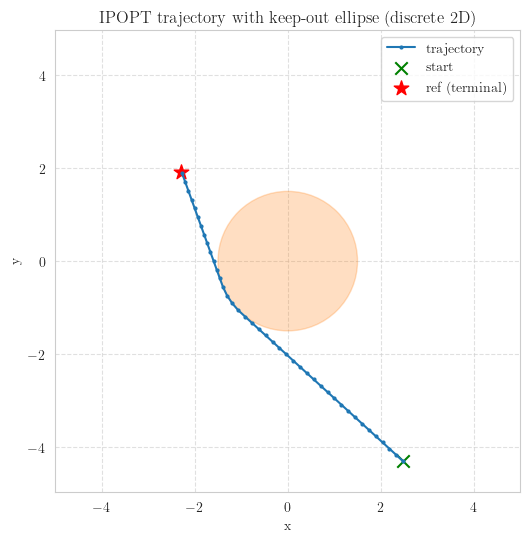

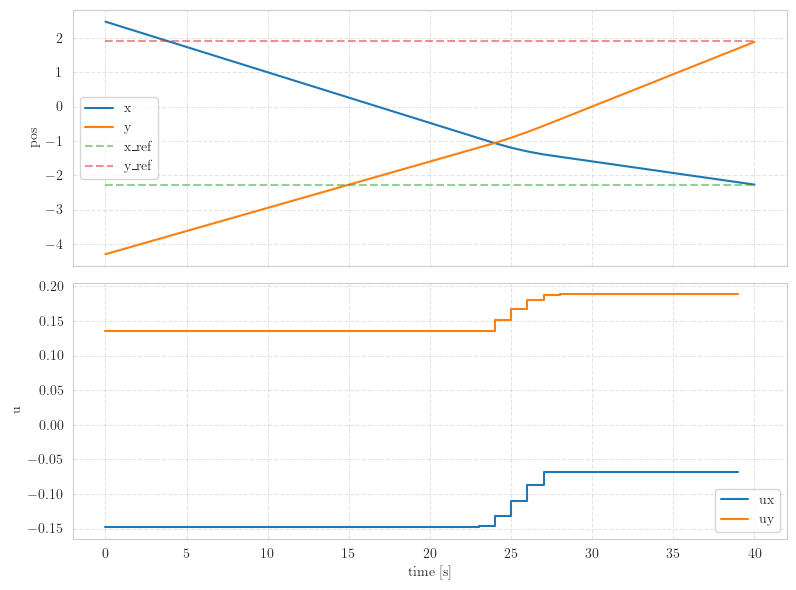

In [128]:

# -------------------- Example call --------------------
# your sample dict:

seed = seed
sample = make_test_sample(
    nx=nx, nsteps=40, seed= seed, device=device,
    ellipse= ellipse_configs,
    init_rect= init_rect,
    ref_rect= ref_rect,
)
scale = 1.
pol_configs = {
    "l1_coef": 0.008,
    "Q_con_obs": 1000.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 20.0,
    "Q_uf": 2.0,
    "Q_v": 2.0,
    "Q_r": 100.0,
    "Q_dx": 0.0,
    "Q_du": 1.0
}
refstep=1

bounds = dict(xmin=xmin, xmax=xmax, umin=umin, umax=umax)

Xsol, Usol, J, *_ = solve_and_plot_ipopt(
    sample,                # expects sample['xn'] shape (1,1,2) and sample['r'] shape (1,N+1,2)
    pol_configs,
    Ad=np.array([[1.0, 0.],
                 [0.0, 1.0]]),
    ts=1.0,
    # optional:
    ellipse_cfg={"p": 3,
                 "b": 1,
                 "c": 0.0,
                 "d": 0.0,
                 "theta": 0.0},
    track_whole_horizon=False,
    bounds=bounds,
)

print(J)


In [129]:
trajectories['u'].sum()

tensor(1.4897, grad_fn=<SumBackward0>)

In [130]:
Usol.sum()

1.4392219501429384

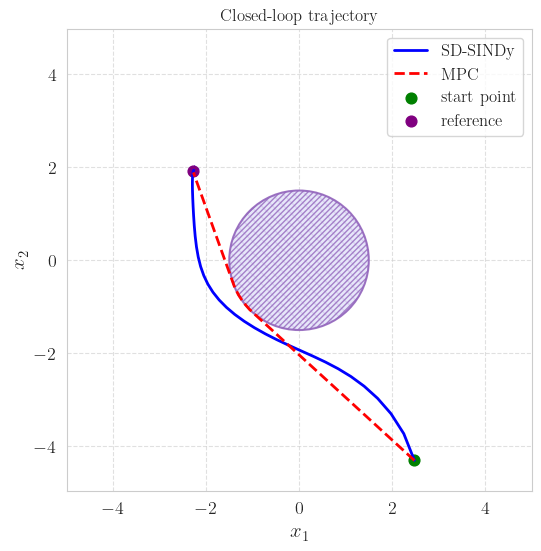

In [131]:
Xsol_reshaped = torch.zeros_like(traj_x)
Xsol_reshaped[:,:,0] = torch.tensor(Xsol[0,:])
Xsol_reshaped[:,:,1] = torch.tensor(Xsol[1,:])

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "SD-SINDy", "color": "blue"},
        {"traj": Xsol_reshaped,   "label": "MPC",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)

In [132]:
import json, torch
from pathlib import Path

policy_lib_cfg = dict(
    n_features=policy_lib.n_features,
    n_control=policy_lib.n_control,
    include_bias=policy_lib.include_bias,
    max_degree=policy_lib.max_degree,
    add_sqrt=policy_lib.add_sqrt,
    add_xu=policy_lib.add_xu,
    add_u_prod=policy_lib.add_u_prod,
    add_fourier=policy_lib.add_fourier,
    max_freq=policy_lib.max_freq,
    is_policy=policy_lib.is_policy,
)

policy_model_cfg = dict(
    n_out=policy_sparse.n_out,
    policy_name=policy_sparse.policy_name,
)

ckpt = {
    "lib_cfg": policy_lib_cfg,
    "model_cfg": policy_model_cfg,
    "active_idx": policy_sparse.active_idx,          # list[list[int]]
    "state_dict": policy_sparse.state_dict(),        # weights
}

builders       = {"SparseDPC": builder_SD_SINDy}   # tag → builder
base_dir       = "results/models/"
# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()
    torch.save(ckpt, str(models_dir) + "/policy_sparse.pt")   # you can call it .pkl if you want
